<a href="https://colab.research.google.com/github/Han891512/RFM-Analysis_2/blob/main/RFM%20Analysis_MY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#First Tital
##Second Tital
-item1
-item2
-item3
**abcde**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df=pd.read_csv('RFM.csv')
df.head()

,Date,InvoNo,CustomerKey,Amount
0,20180413,AP1804933,A1255,9997.02
1,20180423,AP1807826,A1188,9997.02
2,20180424,AP1800872,A0846,9997.02
3,20180426,AP1803170,A1204,9997.02
4,20180501,MA1806692,A0907,9997.02


In [24]:
import pandas as pd

# 假設你的原始資料框叫做 df
# df = pd.DataFrame(...)

# 1. 將Date欄位轉換為 datetime 型態，以確保後續計算正確
df['Date'] = pd.to_datetime(df['Date'])

# 找出資料集中的全域最大Date（即「Date欄最大Date」）
max_date = df['Date'].max()

# 2. 進行 groupby 並計算 Customer, X, Y, Z
# 我們使用 agg() 來一次性計算多個欄位的聚合結果
df_grouped = df.groupby('CustomerKey').agg(
    Customer=('CustomerKey', 'first'),              # 內容為CustomerKey
    X=('InvoNo', 'count'),                   # InvoNo計數
    Y=('Amount', 'sum'),                         # Amount加總
    max_customer_date=('Date', 'max')          # 該客戶的交易最大Date
).reset_index()

# 計算 Z：全域最大Date 與 該客戶交易Date最大值的差額
# .dt.days 可以將時間差（Timedelta）轉為天數整數
df_grouped['Z'] = (max_date.normalize() - df_grouped['max_customer_date'].dt.normalize()).dt.days

# 如果你希望將這四個結果拆成獨立的變數（對應你的描述）：
Customer = df_grouped['Customer']
X = df_grouped['X']
Y = df_grouped['Y']
Z = df_grouped['Z']

# 檢視合併後的 DataFrame
print(df_grouped[['Customer', 'X', 'Y', 'Z']])

    Customer   X            Y  Z
0      A0350  25  51238.11440  0
1      A0351   6  17890.31200  0
2      A0352  14  46424.03852  0
3      A0353  14  27607.68636  0
4      A0354   6   9973.92064  0
..       ...  ..          ... ..
727    A1413  23  52738.79456  0
728    A1415  20  53019.49664  0
729    A1416  24  49938.38378  0
730    A1419  22  64257.84520  0
731    A1420  14  25054.18342  0

[732 rows x 4 columns]


### 將 RFM 資料進行正規化處理
我們使用 `sklearn.preprocessing.MinMaxScaler` 將特徵值 $X$ (交易次數)、$Y$ (交易總Amount) 與 $Z$ (未交易天數) 縮放到 $[0, 1]$ 區間，並建立新的 DataFrame `nrfm`。

In [4]:
from sklearn.preprocessing import MinMaxScaler

# 複製原有的 grouped dataframe 作為基礎
nrfm = df_grouped[['Customer', 'X', 'Y', 'Z']].copy()

# 進行 Min-Max 正規化
scaler = MinMaxScaler()
nrfm[['X', 'Y', 'Z']] = scaler.fit_transform(nrfm[['X', 'Y', 'Z']])

# 重新命名欄位 (可選，加入 'n' 代表 normalized)
nrfm.columns = ['Customer', 'nX', 'nY', 'nZ']

# 顯示前 5 筆正規化後的結果
display(nrfm.head())

,Customer,nX,nY,nZ
0,A0350,0.631579,0.376563,0.0
1,A0351,0.131579,0.127866,0.0
2,A0352,0.342105,0.340662,0.0
3,A0353,0.342105,0.200335,0.0
4,A0354,0.131579,0.068827,0.0


### 繪製手肘圖 (Elbow Chart)
使用 K-means 演算法，針對不同的群組數 $K$（從 1 到 10）計算群內平方和 (Inertia)，並繪製折線圖。手肘轉折點通常代表著最適合的分群數。

C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak o

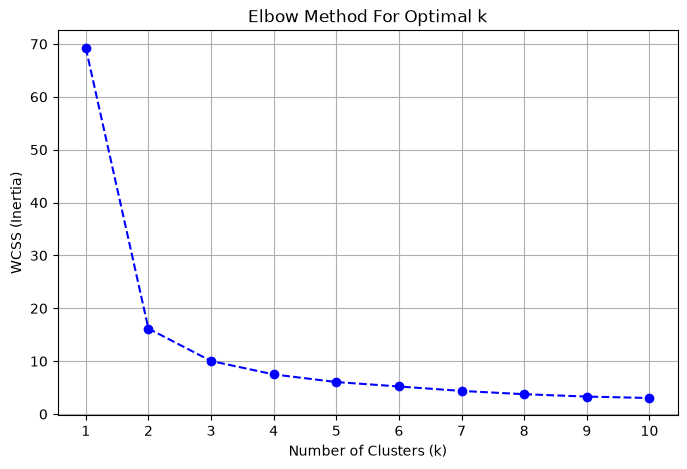

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取正規化後的特徵進行 K-means 評估
features = nrfm[['nX', 'nY', 'nZ']]

wcss = []
# 測試 K 值從 1 到 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# 繪製手肘圖
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### 執行 K-means 分群 (K=4)
使用前面正規化後的特徵 `nX`, `nY`, `nZ` 將資料分成 4 個群組，並將分群結果標籤新增回 `nrfm` 資料框中。

In [6]:
from sklearn.cluster import KMeans

# 設定群組數為 4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# 使用正規化特徵進行擬合與預測
nrfm['Cluster'] = kmeans.fit_predict(nrfm[['nX', 'nY', 'nZ']])

# 顯示各群組的數量分佈
print("各群組客戶數量：")
print(nrfm['Cluster'].value_counts())

# 檢視前 10 筆結果
display(nrfm.head(10))

各群組客戶數量：
Cluster
0    366
1    188
3    108
2     70
Name: count, dtype: int64


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Customer,nX,nY,nZ,Cluster
0,A0350,0.631579,0.376563,0.0,1
1,A0351,0.131579,0.127866,0.0,0
2,A0352,0.342105,0.340662,0.0,3
3,A0353,0.342105,0.200335,0.0,3
4,A0354,0.131579,0.068827,0.0,0
5,A0355,0.184211,0.144389,0.0,0
6,A0356,0.236842,0.111783,0.0,0
7,A0357,0.500000,0.431340,0.0,1
8,A0363,0.078947,0.055714,0.0,0
9,A0365,0.105263,0.092830,0.0,0


In [17]:
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(nrfm[["nX","nY","nZ"]], nrfm.Cluster)

Text(0.5, 0, 'Item No')

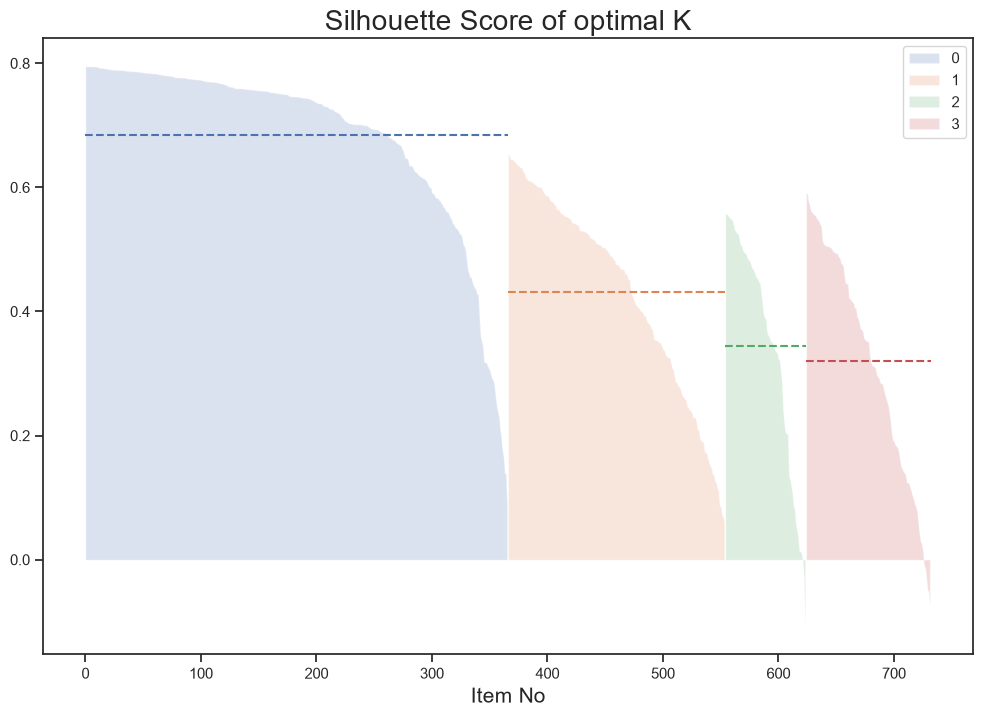

In [20]:
# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

#k=4 #承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):
   
    group_slh=silhouette[nrfm.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿
 
    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線
   
    plt.legend() # 繪製圖例
       
    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)

### 將分群標籤 Cluster 回貼至原始資料 df
我們透過將 `nrfm[['Customer', 'Cluster']]` 與原始資料 `df` 進行合併 (Merge)，藉此為每筆原始交易紀錄貼上對應的客戶分群標籤。

In [7]:
# 建立對照表 (Customer 對應 Cluster)
cluster_mapping = nrfm[['Customer', 'Cluster']]

# 將分群結果合併回原始資料 df，對照鍵為 df 的 CustomerKey 與對照表的 Customer
df = df.merge(cluster_mapping, left_on='CustomerKey', right_on='Customer', how='left')

# 合併後可以將重複的 Customer 欄位刪除
df = df.drop(columns=['Customer'])

# 顯示前 10 筆原始資料，確認 Cluster 標籤已正確貼上
display(df.head(10))

,Date,InvoNo,CustomerKey,Amount,Cluster
0,1970-01-01 00:00:00.020180413,AP1804933,A1255,9997.02,2
1,1970-01-01 00:00:00.020180423,AP1807826,A1188,9997.02,1
2,1970-01-01 00:00:00.020180424,AP1800872,A0846,9997.02,3
3,1970-01-01 00:00:00.020180426,AP1803170,A1204,9997.02,2
4,1970-01-01 00:00:00.020180501,MA1806692,A0907,9997.02,1
5,1970-01-01 00:00:00.020180516,MA1806928,A0808,9997.02,2
6,1970-01-01 00:00:00.020180517,MA1800248,A1146,9997.02,1
7,1970-01-01 00:00:00.020180625,JU1802462,A1374,9997.02,0
8,1970-01-01 00:00:00.020180625,JU1801583,A0745,9997.02,1
9,1970-01-01 00:00:00.020180802,AU1806008,A0690,9997.02,1


### 繪製成對散布圖 (Pair Plot)
我們將分群結果 `Cluster` 整合回未正規化的原始特徵資料（X：交易次數、Y：交易總Amount、Z：未交易天數），並使用 `seaborn.pairplot` 進行視覺化，以 `Cluster` 作為顏色分類 (hue)。

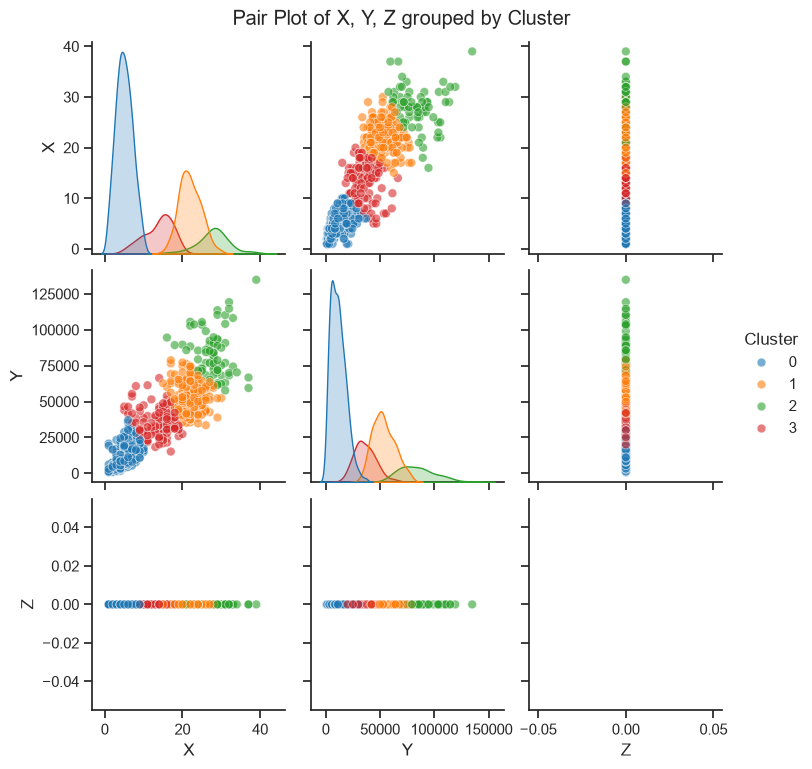

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 將 Cluster 分群結果對照回未正規化的 df_grouped 中
df_analysis = df_grouped.copy()
# 由於 nrfm 與 df_grouped 的 index 與順序一致，可以直接複製 Cluster 欄位
df_analysis['Cluster'] = nrfm['Cluster']

# 繪製 Pair Plot
sns.set_theme(style='ticks')
g = sns.pairplot(
    df_analysis[['X', 'Y', 'Z', 'Cluster']],
    hue='Cluster',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle('Pair Plot of X, Y, Z grouped by Cluster', y=1.02)
plt.show()

### 新增 Group 欄位並對應分群名稱
我們建立一個映射字典，將數值標籤 `Cluster`（0, 1, 2, 3）對應至更具業務意義的群組名稱 `Group`（0 ➡️ Missing, 1 ➡️ High, 2 ➡️ Low, 3 ➡️ Medium）。

In [9]:
# 定義 Cluster 與 Group 的對應關係
cluster_map = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 新增 Group 欄位
df['Group'] = df['Cluster'].map(cluster_map)

# 顯示前 10 筆資料，確認 Group 欄位已正確對應
display(df.head(10))

,Date,InvoNo,CustomerKey,Amount,Cluster,Group
0,1970-01-01 00:00:00.020180413,AP1804933,A1255,9997.02,2,Low
1,1970-01-01 00:00:00.020180423,AP1807826,A1188,9997.02,1,High
2,1970-01-01 00:00:00.020180424,AP1800872,A0846,9997.02,3,Medium
3,1970-01-01 00:00:00.020180426,AP1803170,A1204,9997.02,2,Low
4,1970-01-01 00:00:00.020180501,MA1806692,A0907,9997.02,1,High
5,1970-01-01 00:00:00.020180516,MA1806928,A0808,9997.02,2,Low
6,1970-01-01 00:00:00.020180517,MA1800248,A1146,9997.02,1,High
7,1970-01-01 00:00:00.020180625,JU1802462,A1374,9997.02,0,Missing
8,1970-01-01 00:00:00.020180625,JU1801583,A0745,9997.02,1,High
9,1970-01-01 00:00:00.020180802,AU1806008,A0690,9997.02,1,High


### 繪製成對散布圖 (Pair Plot) - 以 Group 分組
我們將對照好的 `Group` 標籤與未正規化的 `df_grouped` (包含原始 X, Y, Z) 合併，並使用 `seaborn.pairplot` 依 `Group` 進行視覺化分類。

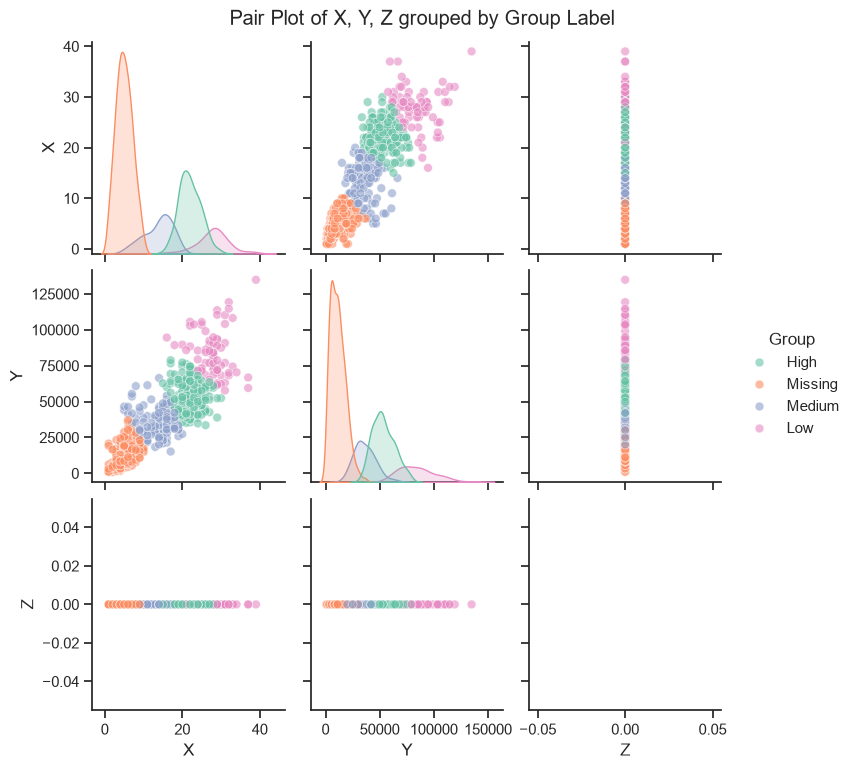

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 將 Group 對應結果與 df_grouped 合併
df_grouped_with_group = df_grouped.copy()
# 透過 nrfm 的 Cluster 來對應 Group
df_grouped_with_group['Cluster'] = nrfm['Cluster']
df_grouped_with_group['Group'] = df_grouped_with_group['Cluster'].map(cluster_map)

# 繪製 Pair Plot，並以 Group 作為分類指標 (hue)
sns.set_theme(style='ticks')
g = sns.pairplot(
    df_grouped_with_group[['X', 'Y', 'Z', 'Group']],
    hue='Group',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle('Pair Plot of X, Y, Z grouped by Group Label', y=1.02)
plt.show()

### 將 Pair Plot 儲存並下載為透明背景 PNG 格式

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# 重新繪製 Pair Plot
sns.set_theme(style='ticks')
g = sns.pairplot(
    df_grouped_with_group[['X', 'Y', 'Z', 'Group']],
    hue='Group',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)
g.fig.suptitle('Pair Plot of X, Y, Z grouped by Group Label', y=1.02)

# 儲存為透明背景 PNG 檔
output_filename = 'RFM_Pairplot.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', transparent=True)
plt.close()

# 觸發瀏覽器下載
files.download(output_filename)

NameError: name 'files' is not defined

### 將包含分群結果的原始資料 df 匯出並下載為 CSV 檔

In [12]:
from google.colab import files

# 將 df 匯出為 CSV 檔，不包含索引值 (index=False)
output_csv = 'RFM_result.csv'
df.to_csv(output_csv, index=False)

# 觸發瀏覽器下載
files.download(output_csv)

ModuleNotFoundError: No module named 'google.colab'